# 3.4. Расчет и результаты

## Truss.solve()

`solve()`

Этот метод вычисляет все опорные реакции и все внутренние усилия во всех стержнях фермы, при условии, что ферма является статически определимой и геометрически неизменяемой (solvable).

Ферма считается разрешимой, если выполняется следующее условие:

2n >= r + m

где n — количество узлов, r — количество опорных реакций (при этом каждая шарнирно-неподвижная опора имеет 2 реакции, а каждая шарнирно-подвижная — 1), и m — количество стержней.

Данное условие вытекает из того факта, что система уравнений разрешима только тогда, когда число неизвестных меньше или равно числу уравнений. Уравнения равновесия в проекциях на оси x и y дают по два уравнения на каждый узел, что в сумме составляет 2n уравнений. Однако ферма также должна быть устойчивой и может быть геометрически изменяемой (unstable), если 2n > r + m. Число переменных представляет собой просто сумму количества опорных реакций и усилий в стержнях.

> [!note]
> Правило знаков для внутренних усилий, возникающих в стержне, основывается на том, является ли каждое усилие сжимающим или растягивающим. При составлении уравнений для каждого узла внутреннее усилие, действующее со стороны стержня на узел, принимается направленным от узла, т.е. по умолчанию каждое усилие считается сжимающим. Следовательно, положительное значение внутреннего усилия указывает на наличие в стержне сжимающей силы, а отрицательное значение — растягивающей силы.

### Пример

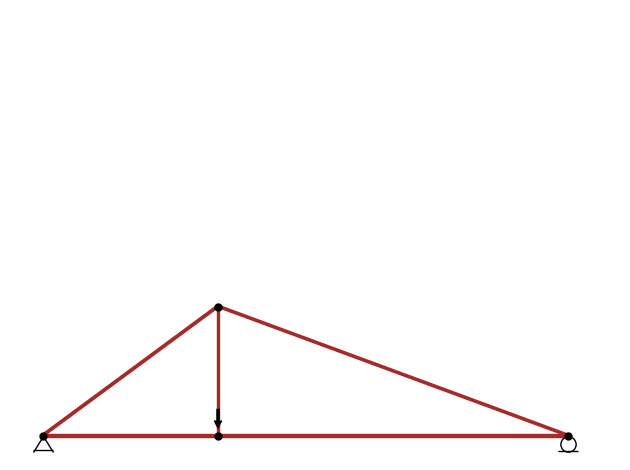

{'R_node_1_x': 0, 'R_node_1_y': 20/3, 'R_node_2_y': 10/3}
{'member_1': 20/3, 'member_2': 20/3, 'member_3': -20*sqrt(2)/3, 'member_4': -10*sqrt(5)/3, 'member_5': 10}


In [3]:
from sympy.physics.continuum_mechanics.truss import Truss
t = Truss()
t.add_node(("node_1", 0, 0), ("node_2", 6, 0), ("node_3", 2, 2), ("node_4", 2, 0))
t.add_member(("member_1", "node_1", "node_4"), ("member_2", "node_2", "node_4"), ("member_3", "node_1", "node_3"))
t.add_member(("member_4", "node_2", "node_3"), ("member_5", "node_3", "node_4"))
t.apply_load(("node_4", 10, 270))
t.apply_support(("node_1", "pinned"), ("node_2", "roller"))
t.solve()
t.draw().show()
print(t.reaction_loads)
print(t.internal_forces)


## Truss.reaction_loads

`property reaction_loads`

Возвращает опорные реакции всех опор (изначально инициализированы нулевыми значениями)

## Truss.internal_forces

`property internal_forces`

Возвращает внутренние усилия для всех стержней; по умолчанию все они инициализированы нулём.